# Analisis Dataset Calgary-HTTP (Granularitas Detik)
Notebook ini memproses log akses ASCII **Calgary-HTTP**, mem-parsing data waktu, mengelompokkan request ke virtual microservices, dan melakukan agregasi ke **Requests Per Second (RPS)** tingkat detik.

Dataset ini merepresentasikan beban kerja web server akademik selama hampir 1 tahun (353 hari).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


In [2]:
log_file_path = 'dataset/calgary_access_log'

print("Membaca dan mem-parsing log file Calgary-HTTP secara efisien...")
start_time = time.time()
data = []

with open(log_file_path, 'r', encoding='latin1') as f:
    for i, line in enumerate(f):
        try:
            parts = line.split('"')
            ts_start = parts[0].find('[') + 1
            ts_end = parts[0].find(']')
            # Format: 24/Oct/1994:13:41:41 -0600
            ts_str = parts[0][ts_start:ts_end-6]
            dt = datetime.strptime(ts_str, '%d/%b/%Y:%H:%M:%S')
            
            req_parts = parts[1].split()
            method = req_parts[0]
            filename = req_parts[1]
            
            status_size_parts = parts[2].strip().split()
            status = int(status_size_parts[0])
            size_str = status_size_parts[1]
            size = int(size_str) if size_str.isdigit() else 0
            
            host = parts[0].split()[0]
            
            # Ambil ekstensi file
            ext = filename.split('.')[-1] if '.' in filename else 'no_ext'
            
            data.append((dt, host, method, ext, status, size))
        except Exception:
            continue
        if (i + 1) % 250000 == 0:
            print(f"Selesai memproses {i + 1} baris...")

df = pd.DataFrame(data, columns=['datetime', 'host', 'method', 'extension', 'status', 'size_bytes'])
df['host'] = df['host'].astype('category')
df['method'] = df['method'].astype('category')
df['extension'] = df['extension'].astype('category')
df['status'] = df['status'].astype('uint16')
df['size_bytes'] = df['size_bytes'].astype('uint32')

df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

print(f"Total baris log: {len(df)} (diproses dalam {time.time() - start_time:.2f} detik)")
df.head()


Membaca dan mem-parsing log file Calgary-HTTP secara efisien...


Selesai memproses 250000 baris...


Selesai memproses 500000 baris...


Total baris log: 724863 (diproses dalam 13.46 detik)


,host,method,extension,status,size_bytes
datetime,,,,,
1994-10-24 13:41:41,local,GET,html,200,150
1994-10-24 13:41:41,local,GET,gif,200,1210
1994-10-24 13:43:13,local,GET,html,200,3185
1994-10-24 13:43:14,local,GET,gif,200,2555
1994-10-24 13:43:15,local,GET,gif,200,36403


In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 724863 entries, 1994-10-24 13:41:41 to 1995-10-11 14:14:17
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   host        724863 non-null  category
 1   method      724863 non-null  category
 2   extension   724863 non-null  category
 3   status      724863 non-null  uint16  
 4   size_bytes  724863 non-null  uint32  
dtypes: category(3), uint16(1), uint32(1)
memory usage: 12.5 MB


In [4]:
# Pemetaan ke virtual microservices berdasarkan ekstensi file
# Content_Service -> html, txt, faq, dll. (Dokumen teks)
# Media_Service -> gif, jpg, jpeg, xbm, GIF (Aset gambar)
# DynamicAPI_Service -> cgi, pl (Jika ada) atau ps, qt, dan request POST (Beban komputasi)

html_exts = {'html', 'htm', 'txt', 'faq', 'no_ext'}
image_exts = {'gif', 'jpg', 'jpeg', 'xbm', 'GIF', 'rgb'}

df['service'] = 'Others'
df.loc[df['extension'].isin(html_exts), 'service'] = 'Content_Service'
df.loc[df['extension'].isin(image_exts), 'service'] = 'Media_Service'
df.loc[(df['extension'].str.contains('cgi|pl|php', case=False)) | (df['method'] == 'POST'), 'service'] = 'DynamicAPI_Service'

df['service'] = df['service'].astype('category')
print(df['service'].value_counts())


service
Media_Service         363851
Content_Service       345610
Others                 14969
DynamicAPI_Service       433
Name: count, dtype: int64


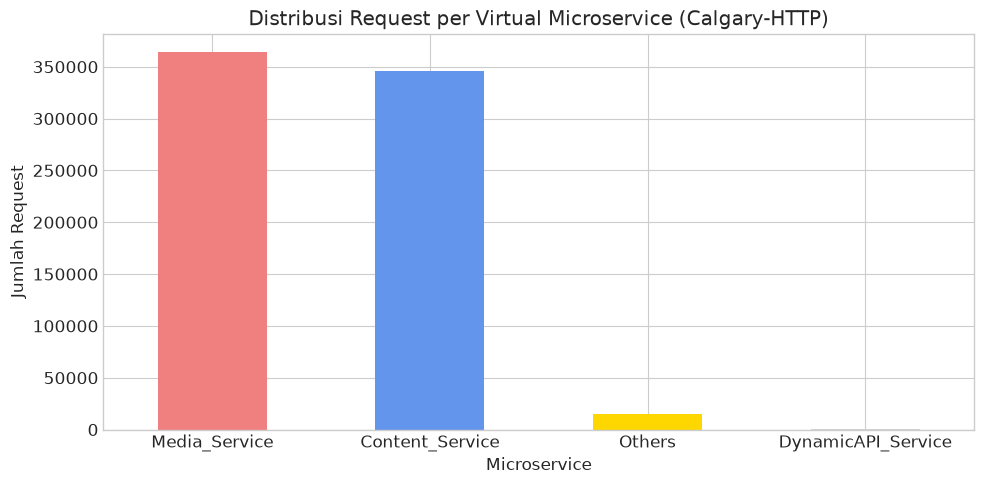

In [5]:
service_counts = df['service'].value_counts()
plt.figure(figsize=(10, 5))
service_counts.plot(kind='bar', color=['lightcoral', 'cornflowerblue', 'gold', 'lightgrey'])
plt.title('Distribusi Request per Virtual Microservice (Calgary-HTTP)')
plt.xlabel('Microservice')
plt.ylabel('Jumlah Request')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [6]:
# Cari 3 hari tersibuk untuk analisis tingkat detik agar tidak OOM
print("Mencari 3 hari tersibuk...")
daily_counts = df.resample('1D').size()
top_days = daily_counts.nlargest(3).index

print(f"Menyaring dan mengagregasi data untuk masing-masing hari tersibuk secara terpisah...")
rps_days = []
for day in top_days:
    day_str = str(day.date())
    df_day = df.loc[day_str]
    
    # Buat range index 24 jam penuh tingkat detik untuk konsistensi
    idx_full = pd.date_range(start=f"{day_str} 00:00:00", end=f"{day_str} 23:59:59", freq='s')
    
    total_rps_day = df_day.resample('1s').size().reindex(idx_full, fill_value=0)
    
    # Resample per-layanan untuk hari ini
    services = df['service'].cat.categories
    rps_services_day = {}
    for svc in services:
        svc_df = df_day[df_day['service'] == svc]
        rps_services_day[svc] = svc_df.resample('1s').size().reindex(idx_full, fill_value=0)
        
    day_df = pd.DataFrame(rps_services_day)
    day_df['total_rps'] = total_rps_day
    rps_days.append(day_df)

# Gabungkan hasil agregasi ketiga hari
rps_df = pd.concat(rps_days)
rps_df.head()


Mencari 3 hari tersibuk...
Menyaring dan mengagregasi data untuk masing-masing hari tersibuk secara terpisah...


,Content_Service,DynamicAPI_Service,Media_Service,Others,total_rps
1995-03-21 00:00:00,0,0,0,0,0
1995-03-21 00:00:01,0,0,0,0,0
1995-03-21 00:00:02,0,0,0,0,0
1995-03-21 00:00:03,0,0,0,0,0
1995-03-21 00:00:04,0,0,0,0,0


In [7]:
# Statistik Deskriptif RPS
stats = rps_df.describe()
print("Statistik Deskriptif RPS per-detik (3 Hari Tersibuk):")
print(stats.loc[['min', 'mean', 'max']])


Statistik Deskriptif RPS per-detik (3 Hari Tersibuk):
      Content_Service  DynamicAPI_Service  Media_Service    Others  total_rps
min          0.000000            0.000000       0.000000  0.000000   0.000000
mean         0.031022            0.000027       0.038962  0.001127   0.071138
max          4.000000            1.000000       9.000000  2.000000   9.000000


Plotting tren harian (RPS rata-rata per hari) untuk seluruh tahun...


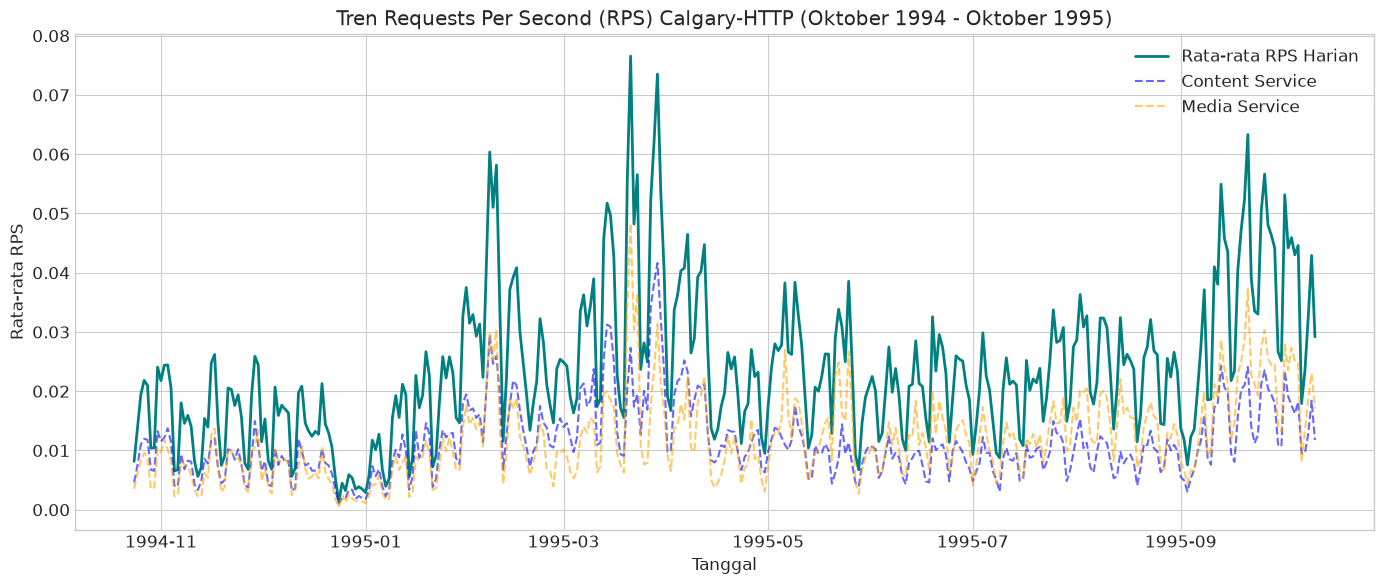

In [8]:
# Plot runtun waktu total RPS (harian agar terlihat tren satu tahun secara efisien)
print("Plotting tren harian (RPS rata-rata per hari) untuk seluruh tahun...")

daily_rps = pd.DataFrame()
daily_rps['total_rps'] = df.resample('1D').size() / 86400.0
daily_rps['Content_Service'] = df[df['service'] == 'Content_Service'].resample('1D').size() / 86400.0
daily_rps['Media_Service'] = df[df['service'] == 'Media_Service'].resample('1D').size() / 86400.0

plt.figure(figsize=(14, 6))
plt.plot(daily_rps.index, daily_rps['total_rps'], label='Rata-rata RPS Harian', color='teal', linewidth=2)
plt.plot(daily_rps.index, daily_rps['Content_Service'], label='Content Service', color='blue', alpha=0.6, linestyle='--')
plt.plot(daily_rps.index, daily_rps['Media_Service'], label='Media Service', color='orange', alpha=0.6, linestyle='--')

plt.title('Tren Requests Per Second (RPS) Calgary-HTTP (Oktober 1994 - Oktober 1995)')
plt.xlabel('Tanggal')
plt.ylabel('Rata-rata RPS')
plt.legend()
plt.tight_layout()
plt.show()


Hari tersibuk: 1995-03-21


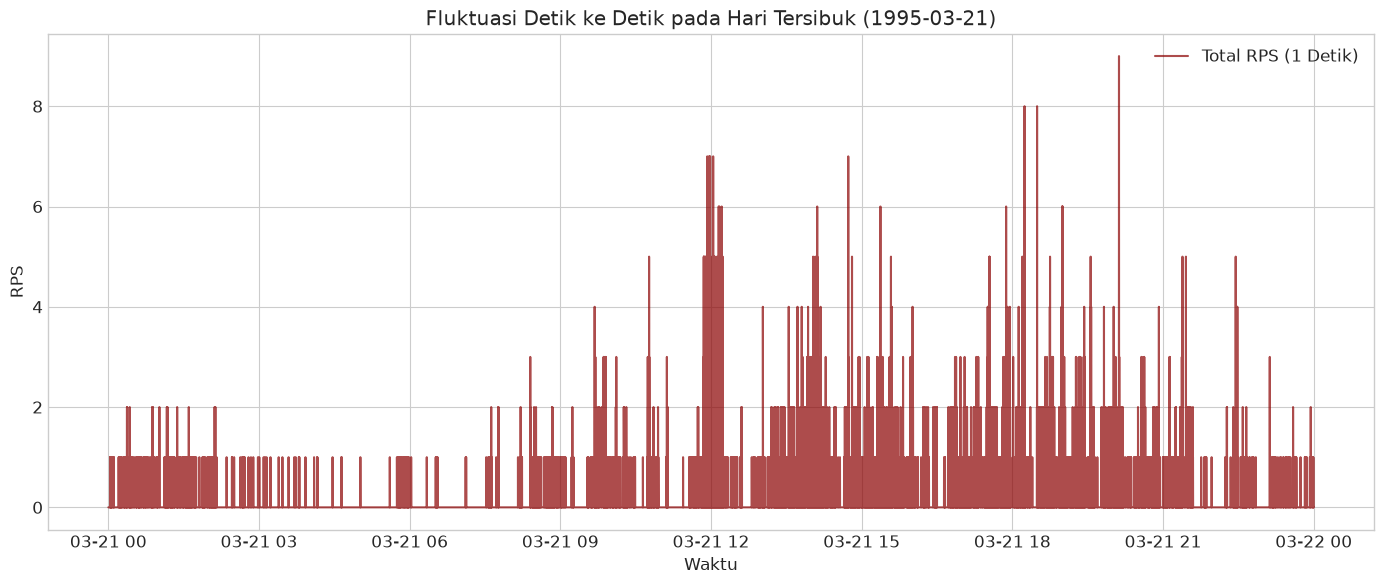

In [9]:
# Cari hari dengan trafik tersibuk di data agregasi
busy_day = rps_df['total_rps'].resample('1D').sum().idxmax()
print(f"Hari tersibuk: {busy_day.date()}")

# Zoom ke hari tersebut (24 jam)
zoomed_df = rps_df.loc[str(busy_day.date())]

plt.figure(figsize=(14, 6))
plt.plot(zoomed_df.index, zoomed_df['total_rps'], label='Total RPS (1 Detik)', color='darkred', alpha=0.7)
plt.title(f'Fluktuasi Detik ke Detik pada Hari Tersibuk ({busy_day.date()})')
plt.xlabel('Waktu')
plt.ylabel('RPS')
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# Simpan hasil agregasi per-detik ke CSV (hanya 3 hari tersibuk)
output_csv_path = 'dataset/aggregated_calgary_rps.csv'
rps_df.to_csv(output_csv_path)
print(f"Dataset hasil agregasi per-detik berhasil disimpan ke: {output_csv_path}")


Dataset hasil agregasi per-detik berhasil disimpan ke: dataset/aggregated_calgary_rps.csv


## Kesimpulan Skenario Autoscaling
Dataset **Calgary-HTTP** merepresentasikan beban kerja web server akademik yang stabil dalam jangka panjang namun memiliki pola musiman (semester/hari libur) dan lonjakan harian yang wajar.